<a href="https://colab.research.google.com/github/tsilva/aiml-notebooks/blob/main/notebooks/wip-gymemu-001-representation-model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gymnasium - Gameplay Frame Latent Compression with Autoencoder - Part 1 - Train Representation Model

## Setup

Install non-optional packages:

In [5]:
!pip install wandb datasets tsilva_notebook_utils==0.0.55

  Using cached datasets-3.5.0-py3-none-any.whl.metadata (19 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 61.7 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2024.12.0 which is incompatible.
torch 2.6.0+cu124 requi

🔑 Loading API keys and authentication tokens from Colab secrets:

In [6]:
from tsilva_notebook_utils.colab import load_secrets_into_env

_ = load_secrets_into_env([
    'WANDB_API_KEY',
    'NOTIFICATION_URL',
    'NOTIFICATION_AUTH_TOKEN'
])

Define configuration:

In [7]:
import os
from tsilva_notebook_utils.colab import notebook_id_from_title

# TODO: increment batch size
# TODO: remove prefixes where obvious
def setup_config():
    # @markdown ### 🏋️ Notebook Settings

    # @markdown Random nb_seed used for reproducibility across runs
    nb_seed = 42  # @param {type: "integer"}

    # @markdown ### 🗂️ Dataset Settings

    # @markdown Dataset ID to load gameplay recordings from
    ds_id = "tsilva/GymnasiumRecording__Tetris_GameBoy"  # @param {type: "string"}
    # @markdown Whether to deduplicate frames
    ds_dedupe_frames = True  # @param {type: "boolean"}
    # @markdown Number of frames to skip between inputs
    ds_frame_skip = 4  # @param {type: "integer"}
    # @markdown Scale factor for input image resizing
    ds_image_scale = 1.0  # @param {type: "number"}
    # @markdown Image mode used
    ds_image_mode = "grayscale"  # @param ["color", "grayscale", "black_and_white"]
    # @markdown Number of colors when quantizing (for black-and-white mode)
    ds_image_quantize_colors = 0  # @param {type: "integer"}
    # @markdown Crop paddings (left, top, right, bottom)
    ds_image_crop_paddings = "0,64,0,16"  # @param {type: "string"}

    # @markdown ### 🏋️️ Training Image Augmentation Settings

    # @markdown Probability of applying augmentation
    aug_prob = 0.0  # @param {type: "number"}
    # @markdown Additional noise during training
    aug_noise_prob = 0.5  # @param {type: "number"}
    # @markdown Additional noise during training
    aug_noise_std = 0.2  # @param {type: "number"}
    # @markdown Probability of flipping
    aug_flip_prob = 0.5  # @param {type: "number"}
    # @markdown Probability of horizontal flip
    aug_hflip_prob = 0.5  # @param {type: "number"}
    # @markdown Probability of vertical flip
    aug_vflip_prob = 0.0  # @param {type: "number"}

    # @markdown ### 🧠 Model Settings

    # @markdown Compile model
    model_compile = True  # @param {type: "boolean"}
    # @markdown Dimensionality of the learned latent space
    model_latent_dim = 16  # @param {type: "integer"}
    # @markdown Noise added to the latent representation
    model_latent_noise_factor = 0.0  # @param {type: "number"}
    # @markdown Small constant for latent computations
    model_latent_sparsity_epsilon = 1e-3  # @param {type: "number"}

    # @markdown ### 🏋️ Training Settings

    # @markdown Total number of training epochs
    train_n_epochs = 100  # @param {type: "integer"}
    # @markdown Number of samples per batch
    train_batch_size = 128  # @param {type: "integer"}
    # @markdown Maximum gradient norm for clipping
    train_max_grad_norm = 0  # @param {type: "number"}
    # @markdown L2 weight decay for optimizer
    train_weight_decay = 0  # @param {type: "number"}
    # @markdown Proportion of steps for learning rate warmup
    train_warmup_ratio = 0  # @param {type: "number"}
    # @markdown Loss function used
    train_loss_function = "mse"  # @param ["l1", "mse"]
    # @markdown Weight for sparsity loss
    train_latent_sparsity_loss_alpha = 0.0  # @param {type: "number"}
    # @markdown Optimizer learning rate
    train_learning_rate = 0.001  # @param {type: "number"}
    # @markdown  train_drift amount during training on reconstructions
    train_drift = 1  # @param {type: "integer"}
    # @markdown Number of epochs between validations
    val_epochs = 10  # @param {type: "integer"}

    # Set notebook ID in the environment
    os.environ["NOTEBOOK_ID"] = notebook_id_from_title()

    return dict(
        # Notebook
        nb_seed=nb_seed,

        # Training Image Augmentation
        aug_prob=aug_prob,
        aug_noise_prob=aug_noise_prob,
        aug_noise_std=aug_noise_std,
        aug_flip_prob=aug_flip_prob,
        aug_hflip_prob=aug_hflip_prob,
        aug_vflip_prob=aug_vflip_prob,

        # Dataset
        ds_id=ds_id,
        ds_dedupe_frames=ds_dedupe_frames,
        ds_frame_skip=ds_frame_skip,
        ds_image_scale=ds_image_scale,
        ds_image_mode=ds_image_mode,
        ds_image_quantize_colors=ds_image_quantize_colors,
        ds_image_crop_paddings=ds_image_crop_paddings,

        # Model
        model_compile=model_compile,
        model_latent_dim=model_latent_dim,
        model_latent_noise_factor=model_latent_noise_factor,
        model_latent_sparsity_epsilon=model_latent_sparsity_epsilon,

        # Training
        train_n_epochs=train_n_epochs,
        train_batch_size=train_batch_size,
        train_max_grad_norm=train_max_grad_norm,
        train_weight_decay=train_weight_decay,
        train_warmup_ratio=train_warmup_ratio,
        train_loss_function=train_loss_function,
        train_learning_rate=train_learning_rate,
        train_latent_sparsity_loss_alpha=train_latent_sparsity_loss_alpha,
        train_drift=train_drift,
        val_epochs=val_epochs
    )

CONFIG = setup_config()

Enable cudnn benchmarking to select optimal cuda kernels:

In [8]:
#import torch
#torch.backends.cudnn.benchmark = True

Login to wandb:

In [9]:
from wandb import login
login()

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: tsilva to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

Load dataset:

In [10]:
from datasets import load_dataset
raw_dataset = load_dataset(CONFIG["ds_id"], split="train")
raw_dataset

README.md:   0%|          | 0.00/389 [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/15.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/36054 [00:00<?, ? examples/s]

Dataset({
    features: ['episode_id', 'image', 'step', 'action'],
    num_rows: 36054
})

Deduplicate dataset:

In [12]:
from tsilva_notebook_utils.datasets import dedupe_dataset
deduped_dataset = dedupe_dataset(raw_dataset, "image") if CONFIG["ds_dedupe_frames"] else raw_dataset.map(lambda x:x, batched=True)
deduped_dataset

Filter:   0%|          | 0/36054 [00:00<?, ? examples/s]

Dataset({
    features: ['episode_id', 'image', 'step', 'action'],
    num_rows: 5012
})

Show sample dataset image:

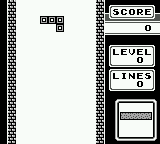

In [13]:
sample_image = deduped_dataset[0]["image"]
sample_image

Test image processing settings:

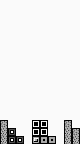

In [20]:
from tsilva_notebook_utils.datasets import process_images
from torchvision.transforms.functional import to_pil_image

PROCESS_IMAGE_CONFIG = {
    "mode" : CONFIG["ds_image_mode"],
    "quantize_colors" : CONFIG["ds_image_quantize_colors"],
    "scale" : CONFIG["ds_image_scale"],
    "crop_paddings" : [int(x) for x in CONFIG["ds_image_crop_paddings"].split(",")]
}
processed_image_t = process_images([deduped_dataset[400]["image"]], **PROCESS_IMAGE_CONFIG)[0]
processed_image = to_pil_image(processed_image_t)
processed_image

Retrieve image dimensions:

In [21]:
image_channels, image_height, image_width = processed_image_t.shape
image_channels, image_height, image_width

(1, 144, 80)

Process all images in dataset:

In [22]:
def _map_process_images(batch):
    xs = process_images(batch["image"], **PROCESS_IMAGE_CONFIG)
    return dict(x=xs, y=xs)

processed_dataset = deduped_dataset.map(
    _map_process_images,
    batched=True,
    batch_size=64
)

Map:   0%|          | 0/5012 [00:00<?, ? examples/s]

Create train and validation datasets (validation dataset only has every Nth frame, train dataset has all frames except those):

In [23]:
import torch
from torch.utils.data import DataLoader

# TODO: split based on episodes instead
ds_frame_skip = CONFIG['ds_frame_skip']
test_dataset = processed_dataset.remove_columns(['episode_id', 'image', 'step'])
test_dataset = test_dataset.with_format("torch")
mask = torch.arange(len(test_dataset)) % ds_frame_skip == 0
train_dataset = test_dataset.select(torch.nonzero(~mask).squeeze()).with_format("torch")
validation_dataset = test_dataset.select(torch.nonzero(mask).squeeze()).with_format("torch")
train_dataset, validation_dataset

(Dataset({
     features: ['action', 'x', 'y'],
     num_rows: 3759
 }),
 Dataset({
     features: ['action', 'x', 'y'],
     num_rows: 1253
 }))

Create dataset loaders:

In [24]:
import multiprocessing
from tsilva_notebook_utils.datasets import AugmentedImageDataset
from tsilva_notebook_utils.video import render_video_from_dataloader

augmented_train_dataset = AugmentedImageDataset(
    train_dataset,
    prob=CONFIG["aug_prob"],
    noise_prob=CONFIG["aug_noise_prob"],
    noise_std=CONFIG["aug_noise_std"],
    flip_prob=CONFIG["aug_flip_prob"],
    hflip_prob=CONFIG["aug_hflip_prob"],
    vflip_prob=CONFIG["aug_vflip_prob"]
)

train_loader = DataLoader(
    augmented_train_dataset,
    batch_size=CONFIG["train_batch_size"],
    shuffle=True,
    pin_memory=True,
    num_workers=multiprocessing.cpu_count(),
    prefetch_factor=4
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=CONFIG["train_batch_size"],
    pin_memory=True,
    shuffle=False,
    num_workers=multiprocessing.cpu_count(),
    prefetch_factor=4
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG["train_batch_size"],
    pin_memory=True,
    shuffle=False,
    num_workers=multiprocessing.cpu_count()
)

render_video_from_dataloader(train_loader, scale=2)

Create the model:

In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from datasets import load_dataset
from tsilva_notebook_utils.torch import get_current_device

class ConvAutoencoder(nn.Module):
    def __init__(self, input_channels, output_channels, input_height, input_width, model_latent_dim=None, use_bottleneck=True):
        super(ConvAutoencoder, self).__init__()

        self.model_latent_noise_factor = CONFIG['model_latent_noise_factor']

        if model_latent_dim is None: model_latent_dim = CONFIG['model_latent_dim']
        self.use_bottleneck = use_bottleneck

        # --- Encoder ---
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(input_channels, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # Dummy forward pass to compute shape
        with torch.no_grad():
            dummy_input = torch.zeros(1, input_channels, input_height, input_width)
            dummy_output = self.encoder_conv(dummy_input)
            self._flattened_size = dummy_output.numel()
            self._conv_output_shape = dummy_output.shape[1:]

        if self.use_bottleneck:
            self.fc_enc = nn.Linear(self._flattened_size, model_latent_dim)
            self.fc_dec = nn.Linear(model_latent_dim, self._flattened_size)

        # --- Decoder ---
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 2, stride=2),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, 2, stride=2),
            nn.ReLU(),

            nn.ConvTranspose2d(32, output_channels, 2, stride=2),
            nn.Sigmoid()
        )

    def encode(self, x):
        x = self.encoder_conv(x)
        if self.use_bottleneck:
            x = x.view(x.size(0), -1)
            x = self.fc_enc(x)
        return x

    def decode(self, z):
        if self.use_bottleneck:
            z = self.fc_dec(z)
            z = z.view(z.size(0), *self._conv_output_shape)
        else:
            z = z  # z already in conv shape
        z = self.decoder_conv(z)
        return z

    def forward(self, x):
        z = self.encode(x)

        z_input = z

        # Add noise to latent space
        if self.training and self.model_latent_noise_factor > 0:
            noise = torch.randn_like(z_input) * self.model_latent_noise_factor
            z_input += noise

        out = self.decode(z_input)
        return out, z

model_latent_dim = CONFIG['model_latent_dim']
use_bottleneck = model_latent_dim > 0
input_channels = image_channels
output_channels = image_channels
device = get_current_device()
raw_model = ConvAutoencoder(input_channels, output_channels, image_height, image_width, use_bottleneck=use_bottleneck).to(device)
model = torch.compile(raw_model) if CONFIG["model_compile"] else raw_model
model

OptimizedModule(
  (_orig_mod): ConvAutoencoder(
    (encoder_conv): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU()
      (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (7): ReLU()
      (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (fc_enc): Linear(in_features=23040, out_features=16, bias=True)
    (fc_dec): Linear(in_features=16, out_features=23040, bias=True)
    (decoder_conv): Sequential(
      (0): ConvTranspose2d(128, 64, kernel_size=(2, 2), stride=(2, 2))
      (1): ReLU()
      (2): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
      (3): ReLU()
      (4): ConvTranspose2

Test a forward pass through the model to make sure shapes are accurate:

In [26]:
def plot_loader_embeddings(loader):
    from tsilva_notebook_utils.plots import plot_embeddings_with_inputs

    z_list = []
    x_images = []
    for batch in validation_loader:
        x = batch["x"].to(device)
        with torch.no_grad(): y_pred, z = model(x)
        z_list.append(z.detach().cpu())
        x_images.extend([to_pil_image(_x) for _x in x.detach().cpu().unbind(0)])

    z_all = torch.cat(z_list, dim=0)
    z_latent_np = z_all.numpy()
    plot_embeddings_with_inputs(z_latent_np, x_images)

plot_loader_embeddings(test_loader)

/usr/local/lib/python3.11/dist-packages/torch/_inductor/compile_fx.py:194: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(
W0425 14:45:27.446000 216 torch/_inductor/utils.py:1137] [0/0] Not enough SMs to use max_autotune_gemm mode


In [27]:
from tsilva_notebook_utils.video import render_video_from_batches

def decode_zs(zs):
    zs = zs.to(device)
    with torch.no_grad(): logits = model.decode(zs)
    return logits

zs = []
latent_dim = CONFIG['model_latent_dim']
for i in range(latent_dim):
    z = torch.zeros(latent_dim, device=device)
    z[i] = 1.0
    zs.append(z)
zs = torch.stack(zs)

frames_t = decode_zs(zs)
render_video_from_batches(frames_t, fps=10, scale=2)

In [28]:
render_video_from_dataloader(validation_loader, model=model, scale=2)

Create model, loss function and optimizer:

In [29]:
train_loss_function = CONFIG['train_loss_function']
if train_loss_function == 'l1':
    loss_fn = nn.L1Loss()
elif train_loss_function == 'mse':
    loss_fn = nn.MSELoss()
elif train_loss_function == 'ssim':
    from pytorch_msssim import MS_SSIM
    ms_ssim = MS_SSIM(data_range=1.0, size_average=True, channel=image_channels)
    loss_fn = lambda pred, target: 1 - ms_ssim(pred, target)

Run training:

In [30]:
import os
import torch
import random
from torch import autocast
from torch.nn.utils import clip_grad_norm_
from torch.optim.lr_scheduler import LambdaLR
from torch.amp import GradScaler
from tqdm import tqdm
import wandb

from tsilva_notebook_utils.plots import plot_tensor_stats_heatmaps
from tsilva_notebook_utils.torch import get_model_device, get_conv_filter_images

def train(
    model,
    loss_fn,
    train_loader
):
    NOTEBOOK_ID = os.getenv("NOTEBOOK_ID")
    assert NOTEBOOK_ID, "NOTEBOOK_ID environment variable is not set"

    with wandb.init(project=NOTEBOOK_ID, config=CONFIG) as run:
        config = run.config
        train_n_epochs = config["train_n_epochs"]
        train_learning_rate = config["train_learning_rate"]
        train_max_grad_norm = config["train_max_grad_norm"]
        train_warmup_ratio = config["train_warmup_ratio"]
        train_drift = config["train_drift"]
        train_latent_sparsity_loss_alpha = config["train_latent_sparsity_loss_alpha"]
        val_epochs = config["val_epochs"]
        model_latent_sparsity_epsilon = config["model_latent_sparsity_epsilon"]
        train_learning_rate = config["train_learning_rate"]
        train_weight_decay = config["train_weight_decay"]

        optimizer = optim.AdamW(
            model.parameters(),
            lr=train_learning_rate,
            weight_decay=train_weight_decay,
            fused=True
        )

        device = get_model_device(model)
        scaler = GradScaler(enabled=(device.type == "cuda"))
        wandb.watch(model, log="all")

        total_steps = train_n_epochs * len(train_loader)
        warmup_steps = int(train_warmup_ratio * total_steps)

        scheduler = LambdaLR(optimizer, lr_lambda=lambda step: step / max(1, warmup_steps) if step < warmup_steps else 1.0)

        global_step = 0

        for epoch in tqdm(range(train_n_epochs), desc="Training"):
            model.train()
            epoch_losses, reconstruction_losses, sparsity_losses = [], [], []

            epoch_xs, epoch_zs, epoch_logits = [], [], []

            for batch in train_loader:
                x = batch["x"].to(device)
                y = batch["y"].to(device)

                optimizer.zero_grad()
                global_step += 1

                train_drift_losses = []
                train_drift_recon_losses = []
                train_drift_sparsity_losses = []

                with autocast(device_type=device.type, enabled=(device.type == "cuda")):
                    logits, z = None, None
                    _x = x

                    for _ in range(train_drift):
                        _logits, _z = model(_x)

                        recon_loss = loss_fn(_logits, y)
                        latent_alpha = train_latent_sparsity_loss_alpha
                        sparsity_loss = latent_alpha * torch.mean(torch.abs(_z)) if latent_alpha > 0 else 0.0
                        loss = recon_loss + sparsity_loss

                        train_drift_losses.append(loss)
                        train_drift_recon_losses.append(recon_loss)
                        train_drift_sparsity_losses.append(sparsity_loss)

                        if logits is None: logits = _logits
                        if z is None: z = _z
                        _x = _logits

                    epoch_xs.append(x.detach().cpu())
                    epoch_zs.append(z.detach().cpu())
                    epoch_logits.append(logits.detach().cpu())

                # Mean losses over train_drift steps
                loss = torch.stack(train_drift_losses).mean()
                recon_loss = torch.stack(train_drift_recon_losses).mean()
                sparsity_loss = torch.stack(train_drift_sparsity_losses).mean() if latent_alpha > 0 else 0.0

                scaler.scale(loss).backward()

                if train_max_grad_norm:
                    scaler.unscale_(optimizer)
                    clip_grad_norm_(model.parameters(), train_max_grad_norm)

                scaler.step(optimizer)
                scaler.update()
                scheduler.step()

                epoch_losses.append(loss.item())
                reconstruction_losses.append(recon_loss.item())
                if latent_alpha > 0:
                    sparsity_losses.append(sparsity_loss.item())

            # Validation phase
            val_loss = None
            if validation_loader and epoch % val_epochs == 0:
                model.eval()
                val_losses = [
                    loss_fn(model(batch["x"].to(device))[0], batch["y"].to(device)).item()
                    for batch in validation_loader
                ]
                val_loss = sum(val_losses) / len(val_losses)

            epoch_xs = torch.cat(epoch_xs, dim=0)
            epoch_logits = torch.cat(epoch_logits, dim=0)
            epoch_zs = torch.cat(epoch_zs, dim=0)

            # Collect latent stats
            activation_rate = (epoch_zs.abs() > model_latent_sparsity_epsilon).float().mean(dim=0)

            # Logging to wandb
            wandb_stats = {
                "meta/epoch": epoch + 1,
                "meta/step": global_step,
                "meta/learning_rate": scheduler.get_last_lr()[0],
                "train/loss": sum(epoch_losses) / len(epoch_losses),
                "train/reconstruction_loss": sum(reconstruction_losses) / len(reconstruction_losses),
                "latent_z/sparsity": (epoch_zs.abs() < model_latent_sparsity_epsilon).float().mean().item(),
                "latent_z/active_ratio": activation_rate.mean().item(),
                "latent_z/min": epoch_zs.min().item(),
                "latent_z/max": epoch_zs.max().item(),
                "latent_z/mean": epoch_zs.mean().item(),
                "latent_z/std": epoch_zs.std().item(),
                "latent_z/l2_norm": epoch_zs.norm(p=2).item(),
                "latent_z/l1_norm": epoch_zs.norm(p=1).item(),
                "latent_z/hist": wandb.Histogram(epoch_zs.numpy()),
                "latent_z/activation_per_dim": wandb.Histogram(activation_rate.cpu().numpy())
            }

            if sparsity_losses:
                wandb_stats["train/sparsity_loss"] = sum(sparsity_losses) / len(sparsity_losses)

            # Optional latent visualizations
            results = plot_tensor_stats_heatmaps(epoch_zs, title_prefix="Latent Analysis", stats=["mean", "std", "var"])
            for key, image in results.items():
                wandb_stats[f"latent_z/{key}_heatmap"] = wandb.Image(image)

            # Sample one reconstruction pair per step
            sample_idx = random.randrange(len(epoch_xs))
            sample_x = epoch_xs[sample_idx]
            sample_logits = epoch_logits[sample_idx]
            concat_img = torch.cat([sample_x.cpu(), sample_logits.cpu()], dim=2)
            wandb_stats["reconstruction/pair"] = wandb.Image(
                to_pil_image(concat_img),
                caption="x|y_pred"
            )

            filter_images = get_conv_filter_images(model)
            for key, image in filter_images.items():
                wandb_stats[f"filters/{key}"] = wandb.Image(image)

            if val_loss is not None:
                wandb_stats["val/loss"] = val_loss

            wandb.log(wandb_stats, step=global_step)

        return run

train(model, loss_fn, train_loader)

Training:  22%|██▏       | 22/100 [02:12<07:51,  6.04s/it]
Traceback (most recent call last):
  File "<ipython-input-30-21644c2a3f5b>", line 59, in train
    for batch in train_loader:
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 708, in __next__
    data = self._next_data()
           ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1458, in _next_data
    idx, data = self._get_data()
                ^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1410, in _get_data
    success, data = self._try_get_data()
                    ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1251, in _try_get_data
    data = self._data_queue.get(timeout=timeout)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/queue.py", line 180, in get
    self.not_empty.wait(remainin

latent_z/active_ratio,▁███▇▄▅█▅▅▅▇▇▆█▇▇█▅▅▅▆
latent_z/l2_norm,▁▂▇▇▄▃▄▄▅▅▆▆▆▇▇▇▇▇████
latent_z/max,▁▂▆▆▃▄▄▅▅▅▆▅▆▆▇▇▇█████
latent_z/mean,▁▁▃▅▆▆▆▆▇▆▇▇▇█████████
latent_z/min,█▇▂▂▄▅▅▄▄▄▃▃▃▃▂▂▂▂▁▁▁▁
latent_z/sparsity,█▁▁▁▂▅▄▁▄▄▄▂▂▃▁▂▂▁▄▄▄▃
latent_z/std,▁▂▇▇▄▃▄▄▅▅▆▆▆▇▇▇▇▇████
meta/epoch,▁▁▂▂▂▃▃▃▄▄▄▅▅▅▆▆▆▇▇▇██
meta/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
meta/step,▁▁▂▂▂▃▃▃▄▄▄▅▅▅▆▆▆▇▇▇██
train/loss,█▅▄▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁


KeyboardInterrupt: 

Plot the test dataset embedding post training:

In [ ]:
plot_loader_embeddings(test_loader)

Render video of autoencoder predictions:

In [ ]:
render_video_from_dataloader(test_loader, model=model, scale=2)

In [ ]:
x = 0
for batch in test_loader:
    x+=1
    if x == 10: break
image_t = batch["x"][0]
print(image_t.shape)
to_pil_image(image_t)

In [ ]:
from tsilva_notebook_utils.video import render_video_from_batches
model.eval()

frames = [image_t]
_inputs = image_t.unsqueeze(0)
device = next(model.parameters()).device
_inputs = _inputs.to(device)
for _ in range(50):
    with torch.no_grad(): predictions = model(_inputs)
    if isinstance(predictions, tuple): predictions = predictions[0]
    _inputs = predictions
    frames.extend(predictions.unbind(0))
render_video_from_batches(frames, scale=2, fps=10)

In [ ]:
from tsilva_notebook_utils.torch import get_model_device
from tsilva_notebook_utils.video import render_video_from_batches

def encode_loader(loader):
    zs = []
    for batch in test_loader:
      x_batch = batch["x"].to(device)
      with torch.no_grad(): z = model.encode(x_batch)
      zs.append(z.detach().cpu())
    zs = torch.cat(zs)
    return zs

zs = encode_loader(test_loader)
mean = zs.mean(dim=0)
cov = torch.cov(zs.T)
mvn = torch.distributions.MultivariateNormal(mean, covariance_matrix=cov)
zs = mvn.sample((1000,))
logits = decode_zs(zs)
frames_t = logits.unbind(0)
render_video_from_batches(frames_t, frame_mapper=lambda x:x)

In [31]:
from tsilva_notebook_utils.huggingface import hf_push_model_to_hub
ds_id = CONFIG["ds_id"]
repo_id =f"{ds_id}-autoencoder"
hf_push_model_to_hub(repo_id, model)

Repository 'tsilva/GymnasiumRecording__Tetris_GameBoy-autoencoder' already exists.


model.pt:   0%|          | 0.00/3.58M [00:00<?, ?B/s]

⏰ Setting up auto-notification and resource management:

In [ ]:
from tsilva_notebook_utils.colab import notify_and_disconnect_after_timeout
notify_and_disconnect_after_timeout()

## Conclusions

- MSE loss trains faster, but L1 loss looks crispier. However, L1 loss requires 10x lower learning rate.